In [1]:
import numpy as np 
import pandas as pd
from src import utils, db, behavmatch
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import clear_output
from pathlib import Path
%matplotlib inline
%load_ext autoreload
%autoreload 2

In [2]:
working_dbase = db.get_sessions().query("recording == True")
working_dbase.loc[:, "name_round"] = working_dbase["mname"] + "_"+ working_dbase["round_id"].astype(str)
sessions = working_dbase["session"].unique()
areas = ['V1', 'medial', 'lateral', 'anterior']
celltype = ['Pyr', 'Int'] 
nmice = working_dbase["name_round"].nunique()
nareas = len(areas)
ncelltypes = len(celltype)
n_sessions = len(sessions)

In [3]:
def get_matched_trials(m):
    object_path = Path(r"D:\mouseobj")
    cbin = 3 
    name, datexp, blk = m.name, m.datexp, m.blk
    save_pth = object_path.joinpath(name,datexp,blk)
    protA = m.trial_dict["rewarded"]
    protB = m.trial_dict["non rewarded"]
    restA = m.trial_dict["rewarded test"]
    restB =  m.trial_dict["non rewarded test"]
    probs = np.load(save_pth.joinpath("probs.npy"), allow_pickle=True)
    prot_matched_trials = behavmatch.match_trials_by_prob_bins(probs, cbin, protA, protB, bins=np.linspace(0, 1, 11), random_state=0)
    rest_matched_trials = behavmatch.match_trials_by_prob_bins(probs, cbin, restA, restB, bins=np.linspace(0, 1, 11), random_state=0)
    m_rew = np.concatenate(prot_matched_trials[:,0]).astype(int)
    m_nrew = np.concatenate(prot_matched_trials[:,1]).astype(int)
    m_rew_test = np.concatenate(rest_matched_trials[:,0]).astype(int)
    m_nrew_test = np.concatenate(rest_matched_trials[:,1]).astype(int)
    trial_dict_matched = {"rewarded": m_rew,
                        "non rewarded": m_nrew,
                        "rewarded test": m_rew_test,
                        "non rewarded test": m_nrew_test}
    return trial_dict_matched

def dprime_cell(response, condition1, condition2, discrimination_region=(0,125), subpop=None):
    """
    Compute the d-prime for a single cell.
    """
    response = response[:,:,discrimination_region[0]:discrimination_region[1]].mean(2)
    r1 = response[:, condition1]
    r2 = response[:, condition2]
    if subpop is not None:
        r1 = r1[subpop]
        r2 = r2[subpop]
    # collect means and stds
    mu1 = r1.mean(1)
    mu2 = r2.mean(1)
    std1 = r1.std(1) + np.finfo(np.float64).tiny
    std2 = r2.std(1) + np.finfo(np.float64).tiny
    #compute the train dprime
    dp = 2 * ((mu1 - mu2) / (std1 + std2))
    return dp

In [ ]:
rows = []
celltype = ['Pyr', 'Int']
areas = ['V1', 'medial', 'lateral', 'anterior']
n_sessions = 5
sessions_names = ['all rewarded before', 'first training', 'last training', 'last training (matched)', 'all rewarded after']
percentils_dp = np.ones((n_sessions, 10, nareas, ncelltypes, 100)) * np.nan
obj_path = Path(r"D:\mouseobj")
for iss, sess in enumerate(sessions_names):
    if sess == 'last training (matched)':
        session = 'last training'
    else:
        session = sess
    d = working_dbase.query(f"session == '{session}'")
    print(f"Processing: {sess}")
    for i, (_, row) in enumerate(d.iterrows()):
        name, datexp, blk = row["mname"], row["datexp"], row["blk"]
        save_pth = obj_path.joinpath(name,datexp,blk)
        m = utils.load_mouse(name, datexp, blk, load_neurons=True, interp_behav=True, load_retinotopy=True, mdl_path=r"D:\mouseobj")
        if sess == 'last training (matched)':
            t_dict = get_matched_trials(m)
            dp = dprime_cell(m.interp_spks, t_dict["rewarded"][::2], t_dict["non rewarded"][::2], discrimination_region=(0,100))
        else:
            t_dict = m.trial_dict
            dp = dprime_cell(m.interp_spks, t_dict["rewarded"][::2], t_dict["non rewarded"][::2], discrimination_region=(0,100))
        for iaa, area in enumerate(areas):
            ia = utils.get_region_idx(m.iarea, area)
            for ic, cell in enumerate(celltype):
                sel_type = np.logical_not(m.isred[:, 0]).astype(bool) if cell == 'Pyr' else m.isred[:, 0].astype(bool)
                pstv_tsh, ngtv_tsh = utils.get_dp_thresholds(dp[ia*sel_type], tsh=95) # top 5%
                prefer_r = (dp>=pstv_tsh)
                prefer_nr = (dp<=ngtv_tsh)
                selective_neurons = prefer_r + prefer_nr
                selection = ia * sel_type * selective_neurons
                sptl_avg = m.interp_spks[:,:,:100].mean(2)
                spks_sel = sptl_avg[selection] # select neurons
                u_rew_prot   = spks_sel[:, t_dict['rewarded'][1::2]].mean(axis=-1)
                u_nrew_prot  = spks_sel[:, t_dict['non rewarded'][1::2]].mean(axis=-1)
                v_rew_nprot  = spks_sel[:, t_dict['rewarded test']].mean(axis=-1)
                v_nrew_nprot = spks_sel[:, t_dict['non rewarded test']].mean(axis=-1)
                u = u_rew_prot - u_nrew_prot
                v = v_rew_nprot - v_nrew_nprot
                dot_product = np.dot(v, u)
                u_sq_norm = np.dot(u, u)
                gain = dot_product / (u_sq_norm + 1e-6)
                v_orthogonal = v - (gain * u)
                orth_dist = np.linalg.norm(v_orthogonal)
                cos_sim = dot_product / ((np.linalg.norm(u) * np.linalg.norm(v)) + 1e-6)
                angle_deg = np.degrees(np.arccos(np.clip(cos_sim, -1.0, 1.0)))

                rows.append({'name': name, 'name_id': row['name_round'], 'datexp': datexp, 'blk': blk, 
                             'session': sess, 'celltype': cell, 'area': area, 'gain': gain, 'orthogonal_distance': orth_dist,
                             'angle_degrees': angle_deg})
    clear_output(wait=True)
gain_decomp = pd.DataFrame(rows)

Processing: all rewarded after
Checking if model object exists ...
Loading mouse object from D:\mouseobj\VG11\2024_11_01\2
Existing mouse object has the following attributes:
dict_keys(['name', 'datexp', 'blk', 'data_path', '_timeline', '_data_var', '_settings', '_timestamps', '_trial_info', '_spks', '_ypos', '_xpos', '_iplane', '_stat', '_ops', '_snr', '_is_cell', 'xy_t', 'iarea', 'iregion', 'outline', 'frameselector', 'isred', 'trial_dict', 'interp_spks', 'train_dp'])
Checking if model object exists ...
Loading mouse object from D:\mouseobj\VG11\2024_11_15\2
Existing mouse object has the following attributes:
dict_keys(['name', 'datexp', 'blk', 'data_path', '_timeline', '_data_var', '_settings', '_timestamps', '_trial_info', '_spks', '_ypos', '_xpos', '_iplane', '_stat', '_ops', '_snr', '_is_cell', 'xy_t', 'iarea', 'iregion', 'outline', 'frameselector', 'isred', 'trial_dict', 'interp_spks', 'train_dp'])
Checking if model object exists ...
Loading mouse object from D:\mouseobj\VG14\20

In [23]:
gain_decomp.to_csv(r"D:\mouseobj\overall\gain_decomp.csv", index=False)

In [24]:
gain_decomp

,name,name_id,datexp,blk,session,celltype,area,gain,orthogonal_distance,angle_degrees
0,VG11,VG11_1,2024_10_15,4,all rewarded before,Pyr,V1,0.051361,7.305514,77.832733
1,VG11,VG11_1,2024_10_15,4,all rewarded before,Int,V1,-0.033519,1.194176,99.431266
2,VG11,VG11_1,2024_10_15,4,all rewarded before,Pyr,medial,0.150829,5.891038,63.893793
3,VG11,VG11_1,2024_10_15,4,all rewarded before,Int,medial,0.080092,0.800275,72.095855
4,VG11,VG11_1,2024_10_15,4,all rewarded before,Pyr,lateral,0.036668,4.247217,82.272870
...,...,...,...,...,...,...,...,...,...,...
387,VGa9,VGa9_1,2025_11_21,2,all rewarded after,Int,medial,0.367570,2.385366,59.310007
388,VGa9,VGa9_1,2025_11_21,2,all rewarded after,Pyr,lateral,0.052675,5.396447,82.997796
389,VGa9,VGa9_1,2025_11_21,2,all rewarded after,Int,lateral,0.105900,0.765115,71.098931
390,VGa9,VGa9_1,2025_11_21,2,all rewarded after,Pyr,anterior,0.123701,4.485219,75.967550


In [26]:
session_order = [
    'all rewarded before', 
    'first training', 
    'last training', 
    'last training (matched)', 
    'all rewarded after'
]
gain_decomp['session'] = pd.Categorical(gain_decomp['session'], categories=session_order, ordered=True)

In [28]:
gain_decomp.groupby(['session', 'area', 'celltype'], observed=True).agg({'gain': ['mean', 'std'], 'angle_degrees': ['mean', 'std']}).reset_index()

session      area celltype      gain            \
                                                    mean       std   
0       all rewarded before        V1      Int  0.169736  0.103077   
1       all rewarded before        V1      Pyr  0.166861  0.103485   
2       all rewarded before  anterior      Int -0.028408  0.712995   
3       all rewarded before  anterior      Pyr  0.135872  0.080157   
4       all rewarded before   lateral      Int  0.156937  0.095933   
5       all rewarded before   lateral      Pyr  0.150008  0.087360   
6       all rewarded before    medial      Int  0.320751  0.154219   
7       all rewarded before    medial      Pyr  0.377736  0.220041   
8            first training        V1      Int  0.207238  0.173207   
9            first training        V1      Pyr  0.183703  0.127869   
10           first training  anterior      Int  0.131549  0.168822   
11           first training  anterior      Pyr  0.166296  0.155897   
12           first training   lateral      Int  0.122633  0.229116   
13           first training   lateral      Pyr  0.180414  0.150604   
14           first training    medial      Int  0.350872  0.356995   
15           first training    medial      Pyr  0.435626  0.276892   
16            last training        V1      Int  0.352885  0.207652   
17            last training        V1      Pyr  0.256501  0.134588   
18            last training  anterior      Int  0.723662  0.404657   
19            last training  anterior      Pyr  0.644623  0.381173   
20            last training   lateral      Int  0.464159  0.405675   
21            last training   lateral      Pyr  0.266779  0.153536   
22            last training    medial      Int  0.533476  0.286302   
23            last training    medial      Pyr  0.508606  0.219717   
24  last training (matched)        V1      Int  0.263493  0.144462   
25  last training (matched)        V1      Pyr  0.235519  0.145951   
26  last training (matched)  anterior      Int  0.537074  0.328001   
27  last training (matched)  anterior      Pyr  0.443466  0.214486   
28  last training (matched)   lateral      Int  0.350439  0.372686   
29  last training (matched)   lateral      Pyr  0.215850  0.140115   
30  last training (matched)    medial      Int  0.481314  0.232529   
31  last training (matched)    medial      Pyr  0.443986  0.223167   
32       all rewarded after        V1      Int  0.244405  0.196876   
33       all rewarded after        V1      Pyr  0.181386  0.118839   
34       all rewarded after  anterior      Int  0.286424  0.405058   
35       all rewarded after  anterior      Pyr  0.261533  0.172908   
36       all rewarded after   lateral      Int  0.148683  0.146066   
37       all rewarded after   lateral      Pyr  0.143403  0.121264   
38       all rewarded after    medial      Int  0.414747  0.295235   
39       all rewarded after    medial      Pyr  0.351247  0.249009   

   angle_degrees             
            mean        std  
0      63.989611  14.912750  
1      63.852023  10.153642  
2      79.751727  35.404299  
3      73.285172   6.084362  
4      64.712717  13.270111  
5      66.519293   8.631154  
6      55.005237  11.406184  
7      53.299424  12.040369  
8      63.592204  15.152088  
9      66.396334   8.431237  
10     75.830615  18.596303  
11     73.462305   7.963254  
12     72.132348  23.052163  
13     68.791560  10.328313  
14     65.470206  21.943270  
15     53.206512  12.115311  
16     53.053286  10.347337  
17     61.195247   8.713758  
18     38.235843  21.294274  
19     41.331956  17.293852  
20     58.549564  27.581045  
21     63.797959  10.116789  
22     43.459777  12.352124  
23     49.153826   9.252880  
24     58.976592  10.151628  
25     63.065291   9.188899  
26     49.675593  24.740057  
27     53.065283  14.586542  
28     62.890021  27.667056  
29     67.165977  11.103155  
30     49.022535   9.814812  
31     53.430848  10.184184  
32     62.975005  16.299719  
33     68.148135   9.842955  

In [9]:
def get_feature_values(df: pd.DataFrame, area: str, celltype: str, session: str, feature: str) -> np.ndarray:
    a = df.query(f"session == '{session}'")
    b = a.query(f"area == '{area}' & celltype == '{celltype}'")
    feature_values= b[feature].values
    return feature_values

def get_feature_fromdf(feature_name: str, df: pd.DataFrame):
    sessions = ['first training', 'last training', 'last training (matched)']
    areas = ['V1', 'medial', 'lateral', 'anterior']
    celltype = ['Pyr', 'Int']
    nmice = 10
    f_dict = {}
    for sess in sessions: 
        fts = np.empty((nmice, len(areas), len(celltype)))
        for ia, area in enumerate(areas):
            for ic, ctype in enumerate(celltype):
                ft = get_feature_values(df, area, ctype, sess, feature_name)
                #store values
                fts[:,ia,ic] = ft
        f_dict[sess] = fts
    df_no34 = df.query("name != 'VG34'")
    sessions = ['all rewarded before', 'all rewarded after']
    nmice = 9
    for sess in sessions: 
        fts = np.empty((nmice, len(areas), len(celltype)))
        for ia, area in enumerate(areas):
            for ic, ctype in enumerate(celltype):
                ft = get_feature_values(df_no34, area, ctype, sess, feature_name)
                #store values
                fts[:,ia,ic] = ft
        f_dict[sess] = fts
    return f_dict   

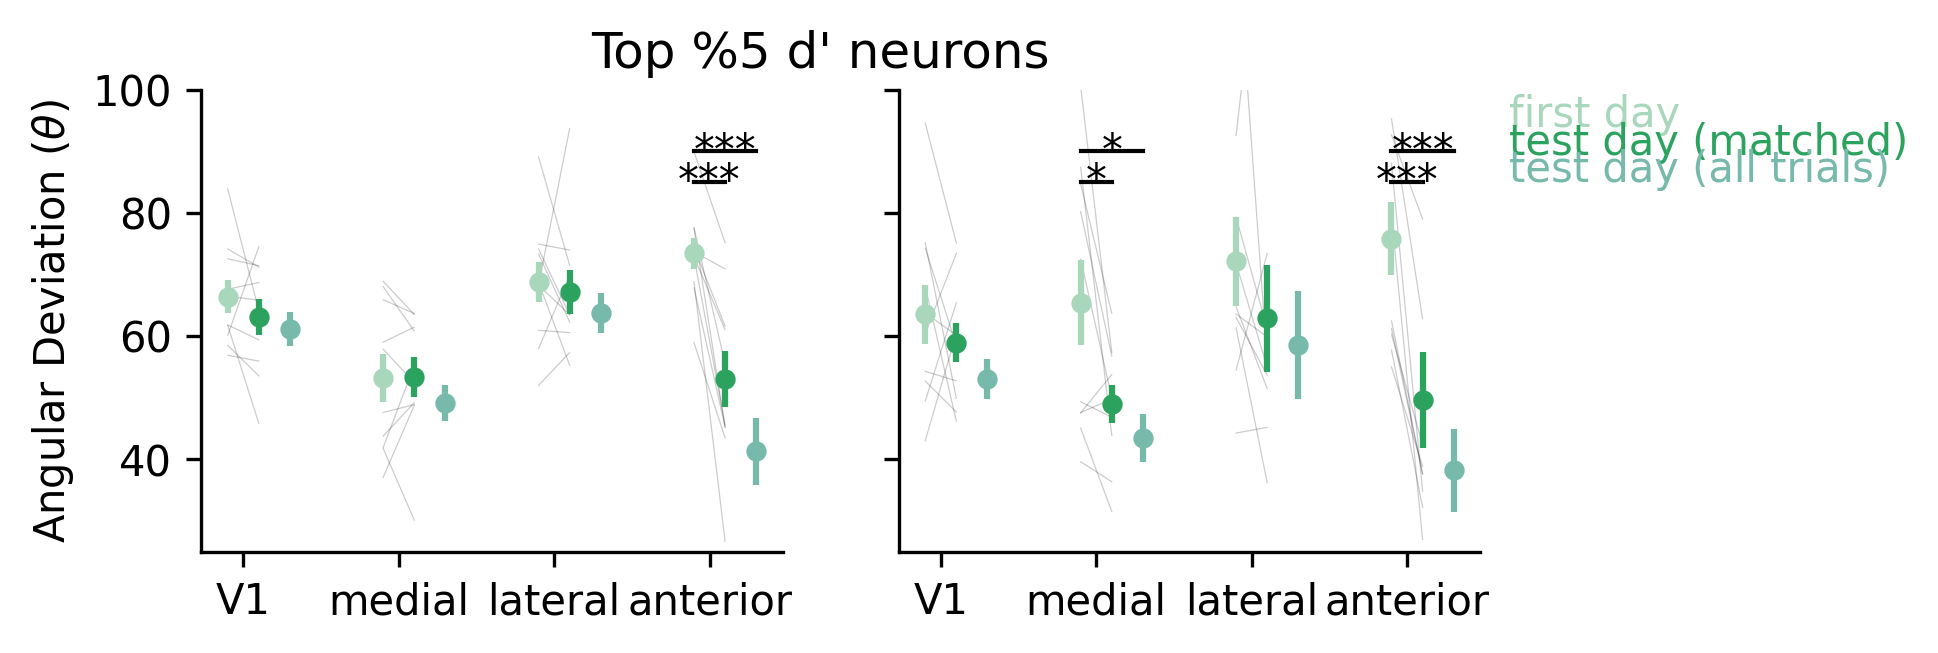

In [49]:
angles = get_feature_fromdf("angle_degrees", gain_decomp)
from src import fig1
gis_first = angles['first training']
gis_last = angles['last training']
gis_last_m = angles['last training (matched)']
fig, ax = plt.subplots(1,2, figsize=(5.5,2), dpi=300, sharey=True)
fig1.plot_gi_comparison_wcontrol(gis_first, gis_last_m,  gis_last, ax, sig_line=85, sig_line_control=90, alternative=("two-sided", "two-sided"), ylabel="Angular Deviation ($\\theta$)")
fig.suptitle('Top %5 d\' neurons')
for a in ax.flatten():
    a.set_ylim(25,100)
sns.despine()

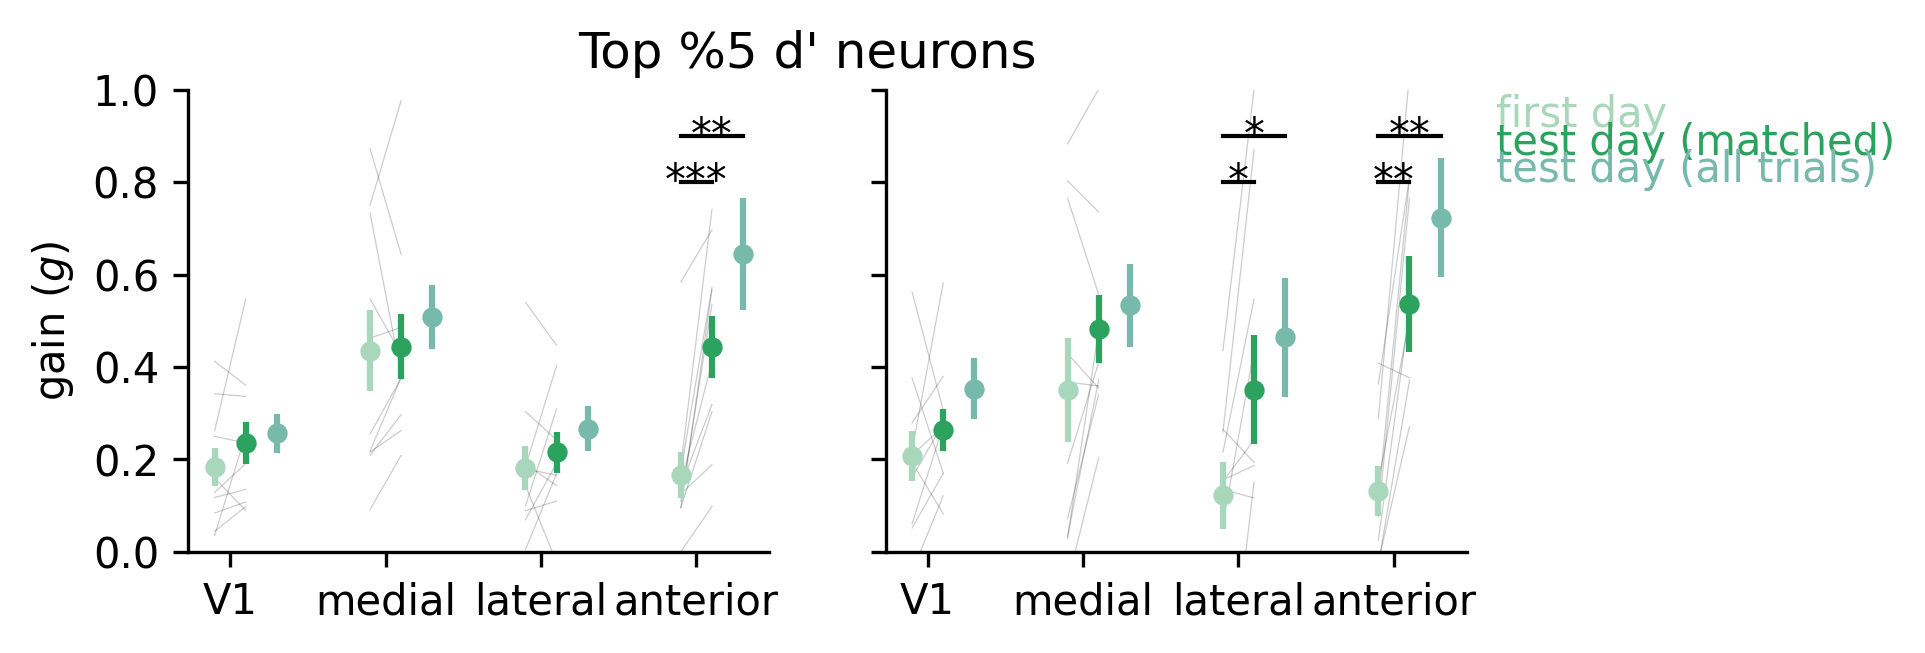

In [53]:
gain = get_feature_fromdf("gain", gain_decomp)
from src import fig1
gis_first = gain['first training']
gis_last = gain['last training']
gis_last_m = gain['last training (matched)']
fig, ax = plt.subplots(1,2, figsize=(5.5,2), dpi=300, sharey=True)
fig1.plot_gi_comparison_wcontrol(gis_first, gis_last_m,  gis_last, ax, sig_line=.8, sig_line_control=.9, alternative=("two-sided", "two-sided"), ylabel="gain ($g$)")
fig.suptitle('Top %5 d\' neurons')
for a in ax.flatten():
    a.set_ylim(0,1)
sns.despine()

In [14]:
import numpy as np
import pandas as pd
from pathlib import Path
from IPython.display import clear_output

rows = []
celltype = ['Pyr', 'Int']
areas = ['V1', 'medial', 'lateral', 'anterior']
n_sessions = 5
sessions_names = ['all rewarded before', 'first training', 'last training', 'last training (matched)', 'all rewarded after']
obj_path = Path(r"D:\mouseobj")

# Configuration for the permutation test
n_shuffles = 100 

for iss, sess in enumerate(sessions_names):
    if sess == 'last training (matched)':
        session = 'last training'
    else:
        session = sess
    d = working_dbase.query(f"session == '{session}'")
    print(f"Processing: {sess}")
    for i, (_, row) in enumerate(d.iterrows()):
        name, datexp, blk = row["mname"], row["datexp"], row["blk"]
        save_pth = obj_path.joinpath(name, datexp, blk)
        m = utils.load_mouse(name, datexp, blk, load_neurons=True, interp_behav=True, load_retinotopy=True, mdl_path=r"D:\mouseobj")
        
        if sess == 'last training (matched)':
            t_dict = get_matched_trials(m)
            dp = dprime_cell(m.interp_spks, t_dict["rewarded"][::2], t_dict["non rewarded"][::2], discrimination_region=(0,100))
        else:
            t_dict = m.trial_dict
            dp = dprime_cell(m.interp_spks, t_dict["rewarded"][::2], t_dict["non rewarded"][::2], discrimination_region=(0,100))
            
        for iaa, area in enumerate(areas):
            ia = utils.get_region_idx(m.iarea, area)
            for ic, cell in enumerate(celltype):
                sel_type = np.logical_not(m.isred[:, 0]).astype(bool) if cell == 'Pyr' else m.isred[:, 0].astype(bool)
                pstv_tsh, ngtv_tsh = utils.get_dp_thresholds(dp[ia*sel_type], tsh=95) # top 5%
                prefer_r = (dp>=pstv_tsh)
                prefer_nr = (dp<=ngtv_tsh)
                selective_neurons = prefer_r + prefer_nr
                selection = ia * sel_type * selective_neurons
                
                sptl_avg = m.interp_spks[:,:,:100].mean(2)
                spks_sel = sptl_avg[selection] # select neurons
                
                # Check to prevent errors if no neurons match the selection criteria
                if spks_sel.shape[0] == 0:
                    continue
                
                u_rew_prot   = spks_sel[:, t_dict['rewarded'][1::2]].mean(axis=-1)
                u_nrew_prot  = spks_sel[:, t_dict['non rewarded'][1::2]].mean(axis=-1)
                v_rew_nprot  = spks_sel[:, t_dict['rewarded test']].mean(axis=-1)
                v_nrew_nprot = spks_sel[:, t_dict['non rewarded test']].mean(axis=-1)
                
                u = u_rew_prot - u_nrew_prot
                v = v_rew_nprot - v_nrew_nprot
                
                # -------------------------------------------------------------
                # 1. ORIGINAL GEOMETRY METRICS (OLS Baseline)
                # -------------------------------------------------------------
                dot_product = np.dot(v, u)
                u_sq_norm = np.dot(u, u)
                gain_ols = dot_product / (u_sq_norm + 1e-6)
                orth_dist_ols = np.linalg.norm(v - (gain_ols * u))
                
                norm_u = np.linalg.norm(u)
                norm_v = np.linalg.norm(v)
                cos_sim = dot_product / ((norm_u * norm_v) + 1e-6)
                angle_deg = np.degrees(np.arccos(np.clip(cos_sim, -1.0, 1.0)))

                # -------------------------------------------------------------
                # 2. TOTAL LEAST SQUARES (TLS) METRICS VIA SVD
                # -------------------------------------------------------------
                X_matrix = np.column_stack((u, v))
                U, S, Vt = np.linalg.svd(X_matrix, full_matrices=False)
                
                
                gain_tls = Vt[0, 1] / (Vt[0, 0] + 1e-6) # The TLS gain is the ratio of the second component to the first component of the first principal component
                orth_dist_tls = np.linalg.norm(v) * np.sin(np.radians(angle_deg))  # Orthogonal distance in TLS is the magnitude of v times the sine of the angle between u and v

                # -------------------------------------------------------------
                # 3. SHUFFLE CONTROL LOOP (Permutation Null Baseline)
                # -------------------------------------------------------------
                shuff_angles = []
                shuff_gains_tls = []
                
                # Pool odd prototype trials together to scramble group identities
                all_prot_trials = np.concatenate([t_dict['rewarded'][1::2], t_dict['non rewarded'][1::2]])
                n_rew_odd = len(t_dict['rewarded'][1::2])
                
                for _ in range(n_shuffles):
                    shuffled_idx = np.random.permutation(all_prot_trials)
                    shuff_rew_idx = shuffled_idx[:n_rew_odd]
                    shuff_nrew_idx = shuffled_idx[n_rew_odd:]
                    
                    u_shuff = spks_sel[:, shuff_rew_idx].mean(axis=-1) - spks_sel[:, shuff_nrew_idx].mean(axis=-1)
                    
                    # Compute Shuffled TLS Gain
                    X_shuff = np.column_stack((u_shuff, v))
                    _, _, Vt_shuff = np.linalg.svd(X_shuff, full_matrices=False)
                    g_shuff_tls = Vt_shuff[0, 1] / (Vt_shuff[0, 0] + 1e-6)
                    shuff_gains_tls.append(g_shuff_tls)
                    
                    # Compute Shuffled Angle
                    cos_shuff = np.dot(v, u_shuff) / ((np.linalg.norm(u_shuff) * norm_v) + 1e-6)
                    ang_shuff = np.degrees(np.arccos(np.clip(cos_shuff, -1.0, 1.0)))
                    shuff_angles.append(ang_shuff)
                
                mean_shuff_angle = np.mean(shuff_angles)
                mean_shuff_gain_tls = np.mean(shuff_gains_tls)

                # -------------------------------------------------------------
                # 4. APPEND ALL RESULTS
                # -------------------------------------------------------------
                rows.append({
                    'name': name, 
                    'name_id': row['name_round'], 
                    'datexp': datexp, 
                    'blk': blk, 
                    'session': sess, 
                    'celltype': cell, 
                    'area': area, 
                    'gain_ols': gain_ols, 
                    'gain_tls': gain_tls,
                    'shuff_gain_tls': mean_shuff_gain_tls,
                    'orthogonal_distance_ols': orth_dist_ols,
                    'orthogonal_distance_tls': orth_dist_tls,
                    'angle_degrees': angle_deg,
                    'shuff_angle_degrees': mean_shuff_angle
                })
                
    clear_output(wait=True)

gain_decomp_tls = pd.DataFrame(rows)

Processing: all rewarded after
Checking if model object exists ...
Loading mouse object from D:\mouseobj\VG11\2024_11_01\2
Existing mouse object has the following attributes:
dict_keys(['name', 'datexp', 'blk', 'data_path', '_timeline', '_data_var', '_settings', '_timestamps', '_trial_info', '_spks', '_ypos', '_xpos', '_iplane', '_stat', '_ops', '_snr', '_is_cell', 'xy_t', 'iarea', 'iregion', 'outline', 'frameselector', 'isred', 'trial_dict', 'interp_spks', 'train_dp'])
Checking if model object exists ...
Loading mouse object from D:\mouseobj\VG11\2024_11_15\2
Existing mouse object has the following attributes:
dict_keys(['name', 'datexp', 'blk', 'data_path', '_timeline', '_data_var', '_settings', '_timestamps', '_trial_info', '_spks', '_ypos', '_xpos', '_iplane', '_stat', '_ops', '_snr', '_is_cell', 'xy_t', 'iarea', 'iregion', 'outline', 'frameselector', 'isred', 'trial_dict', 'interp_spks', 'train_dp'])
Checking if model object exists ...
Loading mouse object from D:\mouseobj\VG14\20

In [15]:
gain_decomp_tls.to_csv(r"D:\mouseobj\overall\gain_decomp_tls.csv", index=False)

In [16]:
session_order = [
    'all rewarded before', 
    'first training', 
    'last training', 
    'last training (matched)', 
    'all rewarded after'
]
gain_decomp_tls['session'] = pd.Categorical(gain_decomp_tls['session'], categories=session_order, ordered=True)

In [17]:
gain_decomp_tls

,name,name_id,datexp,blk,session,celltype,area,gain_ols,gain_tls,shuff_gain_tls,orthogonal_distance_ols,orthogonal_distance_tls,angle_degrees,shuff_angle_degrees
0,VG11,VG11_1,2024_10_15,4,all rewarded before,Pyr,V1,0.051361,0.054442,-11.983531,7.305514,7.305514,77.832733,89.738540
1,VG11,VG11_1,2024_10_15,4,all rewarded before,Int,V1,-0.033519,-0.034941,1.034383,1.194176,1.194176,99.431266,90.780827
2,VG11,VG11_1,2024_10_15,4,all rewarded before,Pyr,medial,0.150829,0.166188,-0.460726,5.891038,5.891038,63.893793,90.112242
3,VG11,VG11_1,2024_10_15,4,all rewarded before,Int,medial,0.080092,0.085299,-10.148273,0.800275,0.800275,72.095855,88.735755
4,VG11,VG11_1,2024_10_15,4,all rewarded before,Pyr,lateral,0.036668,0.039552,-12.216699,4.247217,4.247217,82.272870,89.121307
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
387,VGa9,VGa9_1,2025_11_21,2,all rewarded after,Int,medial,0.367570,0.540518,13.572651,2.385366,2.385366,59.310007,91.387682
388,VGa9,VGa9_1,2025_11_21,2,all rewarded after,Pyr,lateral,0.052675,0.064498,-19.730798,5.396447,5.396447,82.997796,90.826749
389,VGa9,VGa9_1,2025_11_21,2,all rewarded after,Int,lateral,0.105900,0.116951,1.252249,0.765115,0.765115,71.098931,91.361618
390,VGa9,VGa9_1,2025_11_21,2,all rewarded after,Pyr,anterior,0.123701,0.162793,-40.593805,4.485219,4.485219,75.967550,90.537776


Text(0.5, 1.0, 'inhibitory')

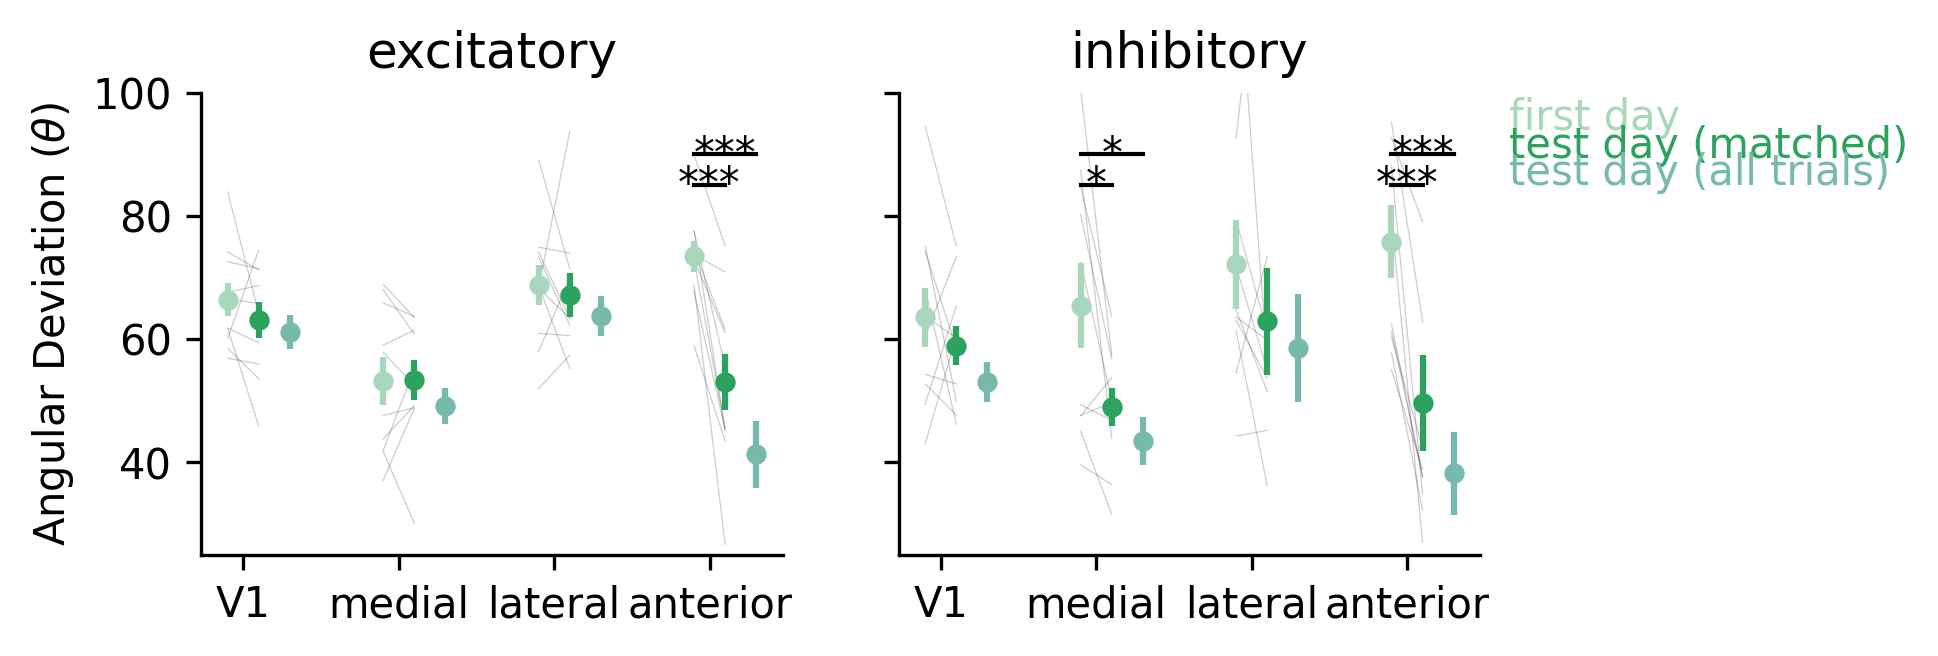

In [18]:
angles = get_feature_fromdf("angle_degrees", gain_decomp_tls)
from src import fig1
gis_first = angles['first training']
gis_last = angles['last training']
gis_last_m = angles['last training (matched)']
fig, ax = plt.subplots(1,2, figsize=(5.5,2), dpi=300, sharey=True)
fig1.plot_gi_comparison_wcontrol(gis_first, gis_last_m,  gis_last, ax, sig_line=85, sig_line_control=90, alternative=("two-sided", "two-sided"), ylabel="Angular Deviation ($\\theta$)")
for a in ax.flatten():
    a.set_ylim(25,100)
sns.despine()
ax[0].set_title("excitatory")
ax[1].set_title("inhibitory")

Text(0.5, 1.0, 'inhibitory')

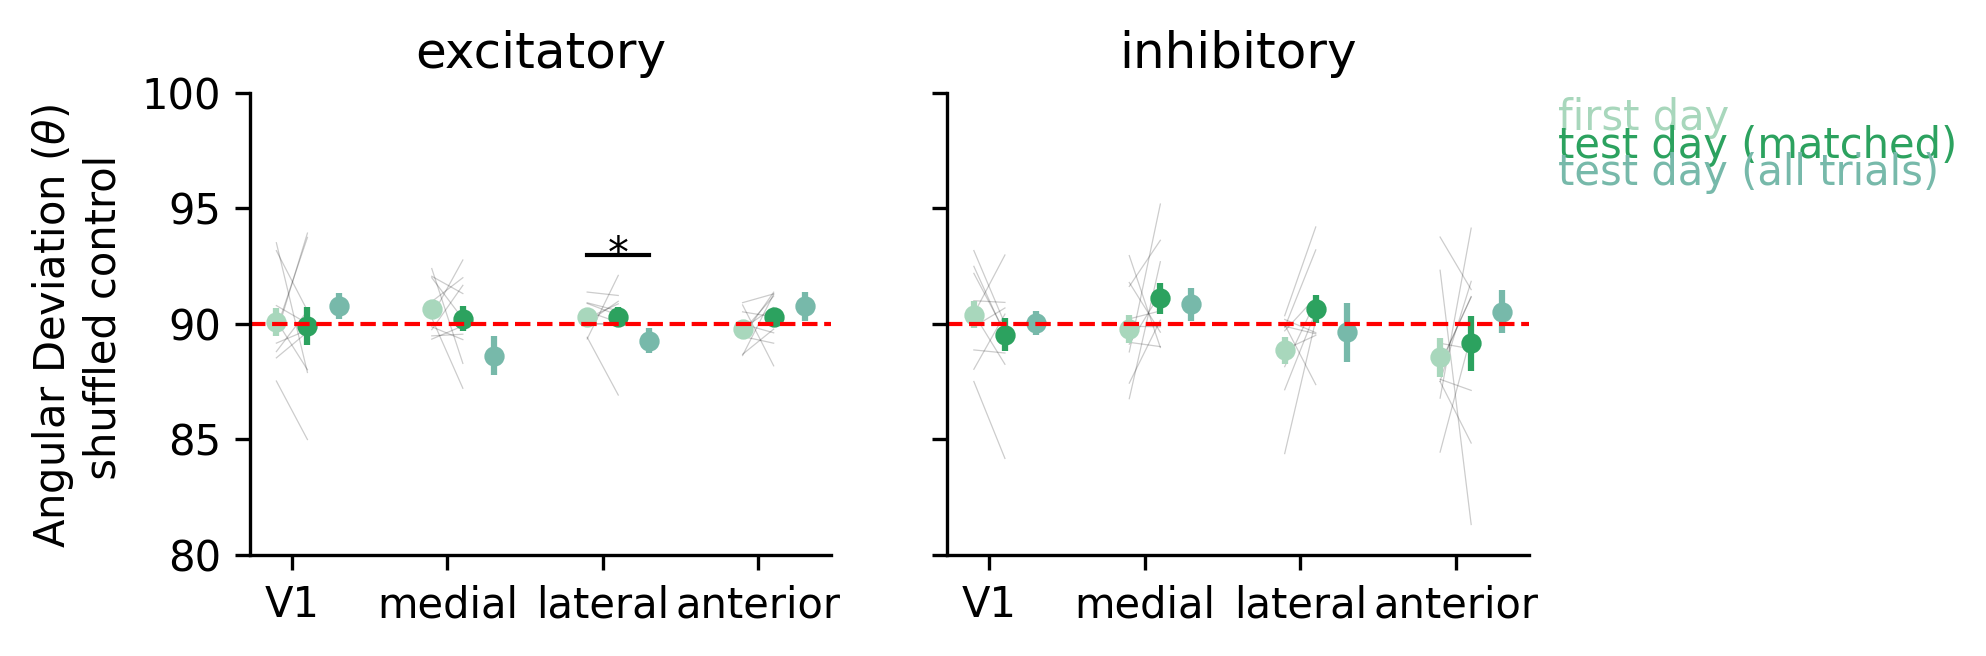

In [19]:
angles = get_feature_fromdf("shuff_angle_degrees", gain_decomp_tls)
from src import fig1
gis_first = angles['first training']
gis_last = angles['last training']
gis_last_m = angles['last training (matched)']
fig, ax = plt.subplots(1,2, figsize=(5.5,2), dpi=300, sharey=True)
fig1.plot_gi_comparison_wcontrol(gis_first, gis_last_m,  gis_last, ax, sig_line=85, sig_line_control=93, alternative=("two-sided", "two-sided"), ylabel="Angular Deviation ($\\theta$) \n shuffled control")
for a in ax.flatten():
    a.set_ylim(80,100)
    a.axhline(y=90, color='r', linestyle='--', linewidth=1)
sns.despine()
ax[0].set_title("excitatory")
ax[1].set_title("inhibitory")

Text(0.5, 1.0, 'inhibitory')

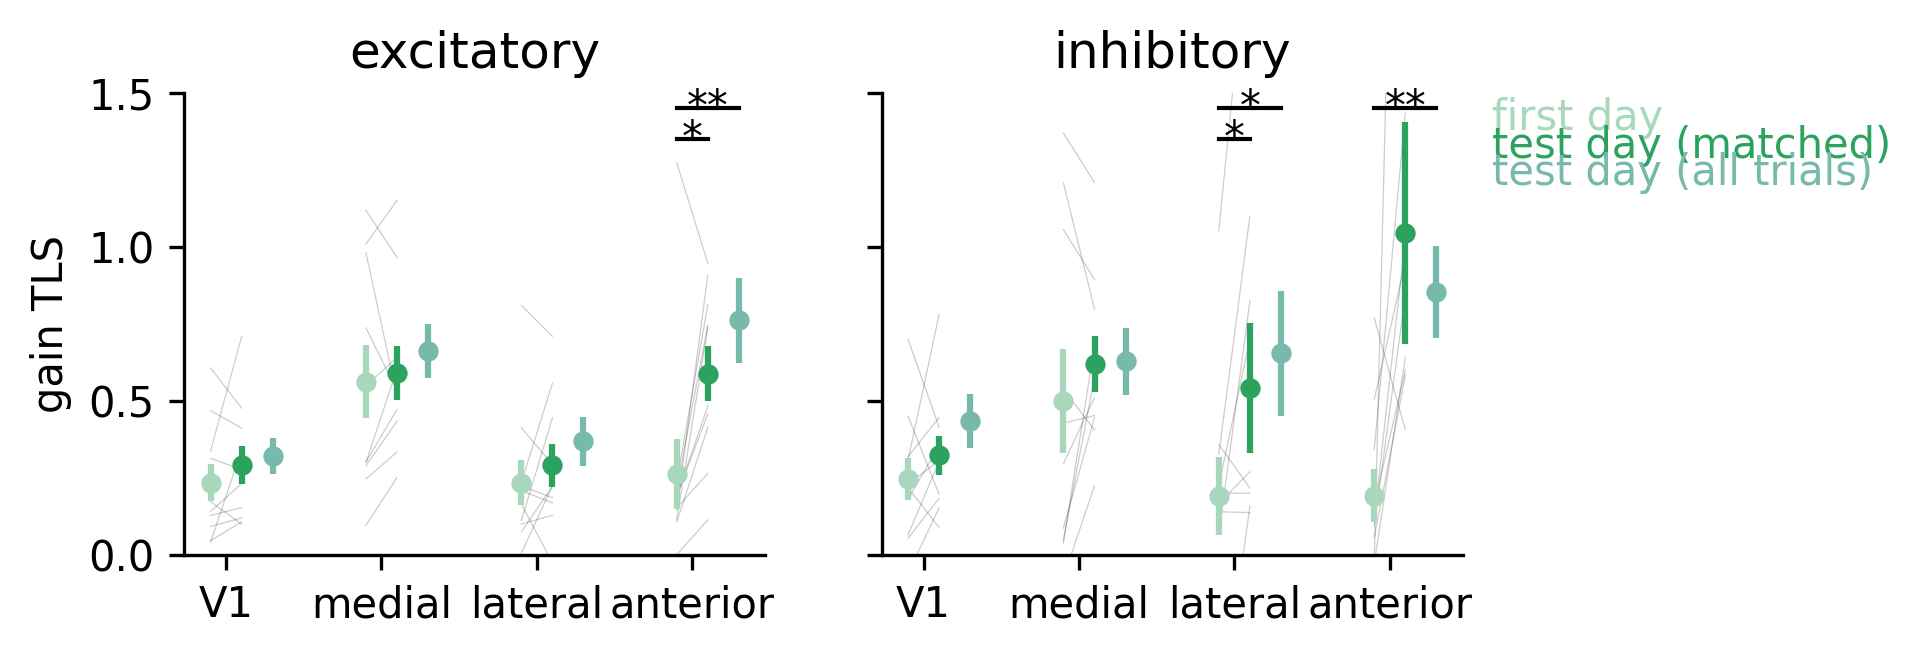

In [20]:
gain = get_feature_fromdf("gain_tls", gain_decomp_tls)
from src import fig1
gis_first = gain['first training']
gis_last = gain['last training']
gis_last_m = gain['last training (matched)']
fig, ax = plt.subplots(1,2, figsize=(5.5,2), dpi=300, sharey=True)
fig1.plot_gi_comparison_wcontrol(gis_first, gis_last_m,  gis_last, ax, sig_line=1.35, sig_line_control=1.45, alternative=("two-sided", "two-sided"), ylabel="gain TLS")
for a in ax.flatten():
    a.set_ylim(0,1.5)
sns.despine()
ax[0].set_title("excitatory")
ax[1].set_title("inhibitory")

Text(0.5, 1.0, 'inhibitory')

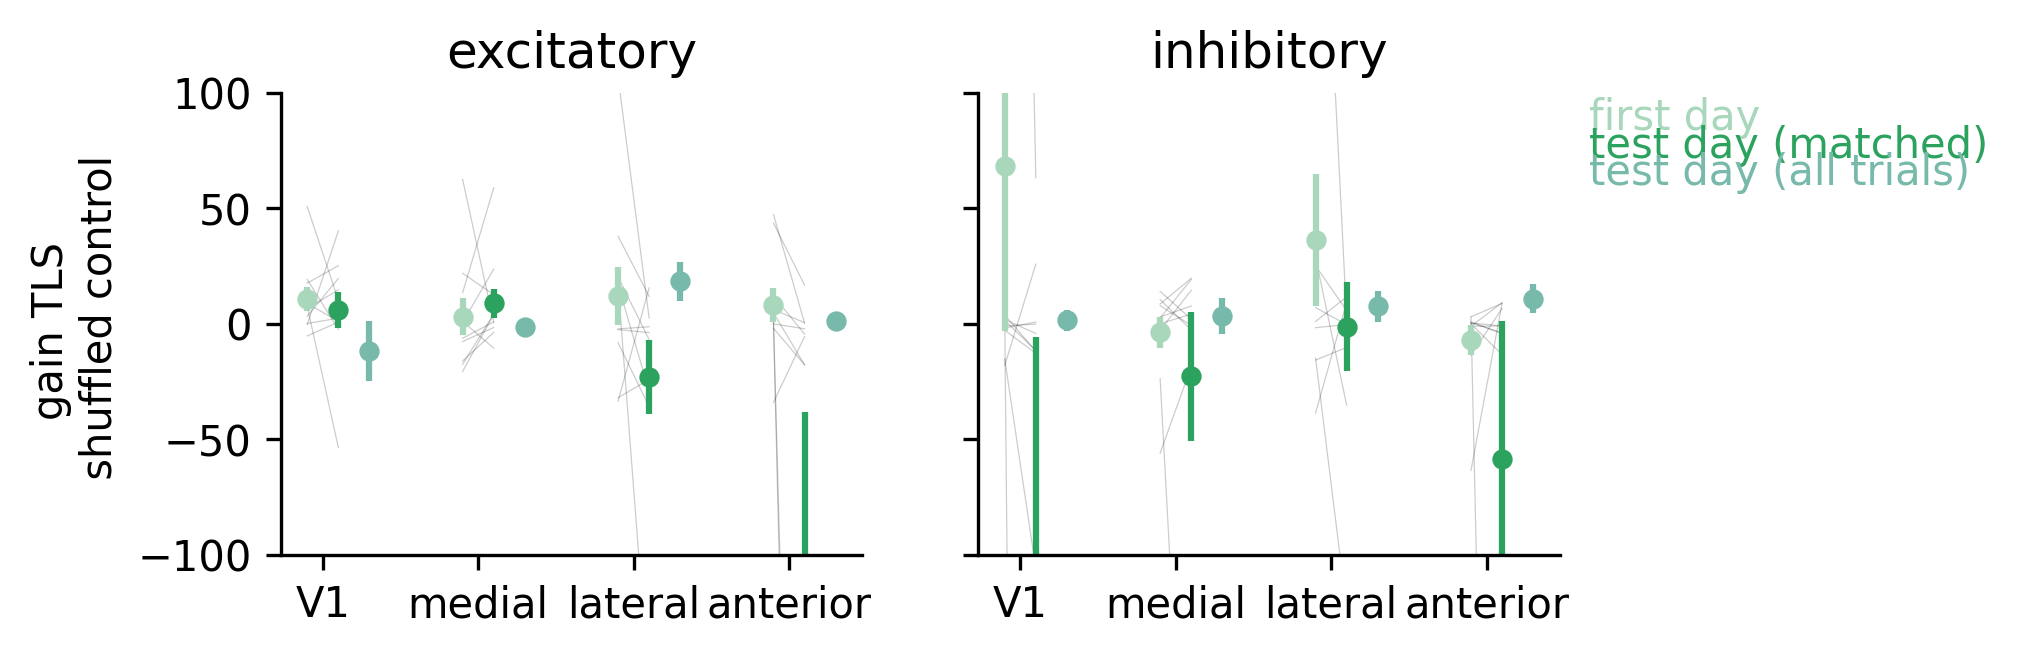

In [21]:
gain = get_feature_fromdf("shuff_gain_tls", gain_decomp_tls)
from src import fig1
gis_first = gain['first training']
gis_last = gain['last training']
gis_last_m = gain['last training (matched)']
fig, ax = plt.subplots(1,2, figsize=(5.5,2), dpi=300, sharey=True)
fig1.plot_gi_comparison_wcontrol(gis_first, gis_last_m,  gis_last, ax, sig_line=1.35, sig_line_control=1.45, alternative=("two-sided", "two-sided"), ylabel="gain TLS \n shuffled control")
for a in ax.flatten():
    a.set_ylim(-100,100)
sns.despine()
ax[0].set_title("excitatory")
ax[1].set_title("inhibitory")

Text(0.5, 1.0, 'inhibitory')

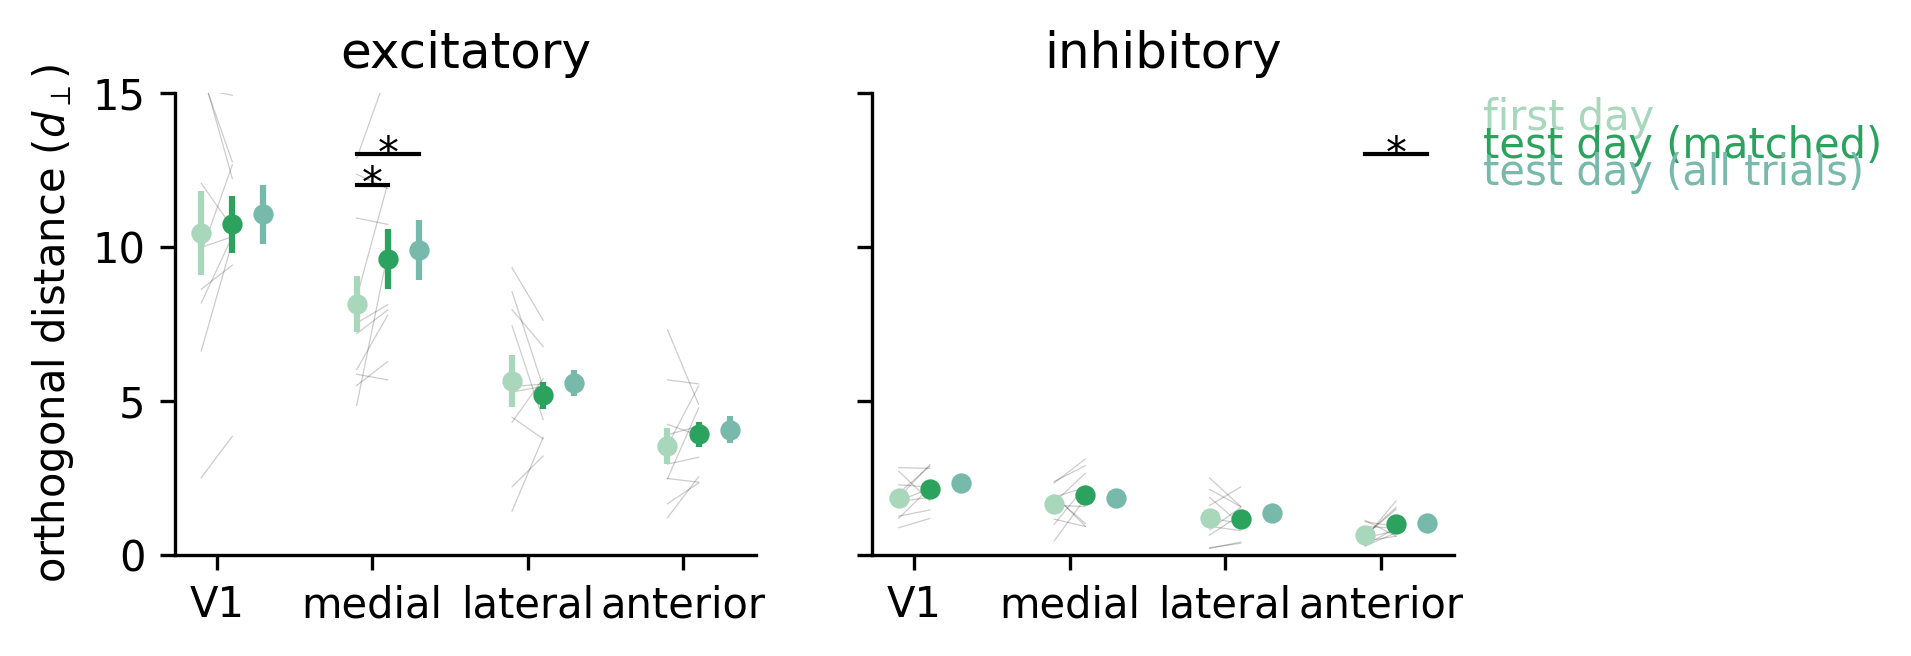

In [26]:
orthogonal_distance = get_feature_fromdf("orthogonal_distance_tls", gain_decomp_tls)
from src import fig1
gis_first = orthogonal_distance['first training']
gis_last = orthogonal_distance['last training']
gis_last_m = orthogonal_distance['last training (matched)']
fig, ax = plt.subplots(1,2, figsize=(5.5,2), dpi=300, sharey=True)
fig1.plot_gi_comparison_wcontrol(gis_first, gis_last_m,  gis_last, ax, sig_line=12, sig_line_control=13, alternative=("two-sided", "two-sided"), ylabel="orthogonal distance ($d_{\\perp}$)")
for a in ax.flatten():
    a.set_ylim(0,15)
sns.despine()
sns.despine()
ax[0].set_title("excitatory")
ax[1].set_title("inhibitory")

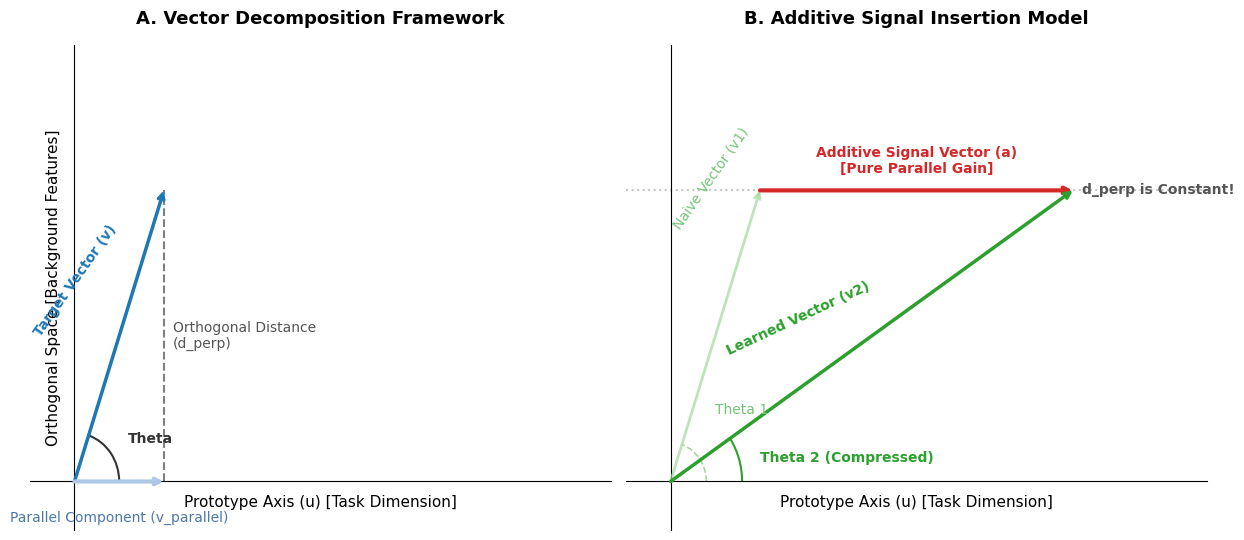

In [87]:
import matplotlib.patches as patches
# Initialize a 1x2 subplot layout
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.5), sharey=True)

# ---------------------------------------------------------
# CONSTANTS & GEOMETRIC COORDINATES
# ---------------------------------------------------------
# Fixed orthogonal height (d_perp) across both conditions
y_ceil = 3.0  

# X-coordinates showing horizontal elongation
x_naive = 1.0
x_learned = 4.5

# ---------------------------------------------------------
# PANEL A: HIGH-DIMENSIONAL DECOMPOSITION
# ---------------------------------------------------------
# Target Vector (v)
ax1.annotate('', xy=(x_naive, y_ceil), xytext=(0, 0),
             arrowprops=dict(arrowstyle="->", lw=2.5, color="#1f77b4", shrinkA=0, shrinkB=0))

# Parallel Component (v_parallel) along the X-axis
ax1.annotate('', xy=(x_naive, 0), xytext=(0, 0),
             arrowprops=dict(arrowstyle="->", lw=3, color="#aec7e8", shrinkA=0, shrinkB=0))

# Orthogonal Distance (d_perp) drop line
ax1.plot([x_naive, x_naive], [0, y_ceil], linestyle='--', color='#7f7f7f', lw=1.5)

# Theta Angle Arc
arc1 = patches.Arc((0, 0), 1.0, 1.0, angle=0, theta1=0, theta2=np.degrees(np.arctan2(y_ceil, x_naive)),
                   color='#333333', lw=1.5)
ax1.add_patch(arc1)

# Labels for Panel A
ax1.text(x_naive / 2, y_ceil / 2, 'Target Vector (v)', color='#1f77b4', fontweight='bold', rotation=55, ha='right')
ax1.text(x_naive + 0.1, y_ceil / 2, 'Orthogonal Distance\n(d_perp)', color='#555555', va='center')
ax1.text(x_naive / 2, -0.3, 'Parallel Component (v_parallel)', color='#4c78a8', ha='center', va='top')
ax1.text(0.6, 0.4, 'Theta', color='#333333', fontweight='bold')

ax1.set_title('A. Vector Decomposition Framework', fontsize=13, fontweight='bold', pad=15)
ax1.set_xlabel('Prototype Axis (u) [Task Dimension]', fontsize=11, labelpad=10)
ax1.set_ylabel('Orthogonal Space [Background Features]', fontsize=11, labelpad=10)

# ---------------------------------------------------------
# PANEL B: THE LEARNING MECHANISM (ADDITIVE INSERTION)
# ---------------------------------------------------------
# Constant Orthogonal Distance Ceiling Line
ax2.axhline(y=y_ceil, linestyle=':', color='#c7c7c7', lw=1.5, zorder=1)

# Naive Target Vector (v1)
ax2.annotate('', xy=(x_naive, y_ceil), xytext=(0, 0),
             arrowprops=dict(arrowstyle="->", lw=2, color="#a1d99b", shrinkA=0, shrinkB=0, alpha=0.7))

# Additive Signal Vector (a) - Purely horizontal insertion
ax2.annotate('', xy=(x_learned, y_ceil), xytext=(x_naive, y_ceil),
             arrowprops=dict(arrowstyle="->", lw=3, color="#d62728", shrinkA=0, shrinkB=0))

# Resultant Learned Target Vector (v2)
ax2.annotate('', xy=(x_learned, y_ceil), xytext=(0, 0),
             arrowprops=dict(arrowstyle="->", lw=2.5, color="#2ca02c", shrinkA=0, shrinkB=0))

# Theta 1 and Theta 2 Arcs
arc_t1 = patches.Arc((0, 0), 0.8, 0.8, angle=0, theta1=0, theta2=np.degrees(np.arctan2(y_ceil, x_naive)),
                     color='#a1d99b', lw=1.2, linestyle='--')
arc_t2 = patches.Arc((0, 0), 1.6, 1.6, angle=0, theta1=0, theta2=np.degrees(np.arctan2(y_ceil, x_learned)),
                     color='#2ca02c', lw=1.5)
ax2.add_patch(arc_t1)
ax2.add_patch(arc_t2)

# Labels for Panel B
ax2.text(x_naive - 0.1, y_ceil - 0.4, 'Naive Vector (v1)', color='#74c476', ha='right', rotation=55)
ax2.text((x_naive + x_learned) / 2, y_ceil + 0.15, 'Additive Signal Vector (a)\n[Pure Parallel Gain]', 
         color='#d62728', fontweight='bold', ha='center', va='bottom')
ax2.text(x_learned / 2, y_ceil / 2 - 0.2, 'Learned Vector (v2)', color='#2ca02c', fontweight='bold', rotation=25, ha='right')
ax2.text(x_learned + 0.1, y_ceil, 'd_perp is Constant!', color='#555555', va='center', fontweight='bold')
ax2.text(0.5, 0.7, 'Theta 1', color='#74c476')
ax2.text(1.0, 0.2, 'Theta 2 (Compressed)', color='#2ca02c', fontweight='bold')

ax2.set_title('B. Additive Signal Insertion Model', fontsize=13, fontweight='bold', pad=15)
ax2.set_xlabel('Prototype Axis (u) [Task Dimension]', fontsize=11, labelpad=10)

# ---------------------------------------------------------
# GLOBAL CLEANUP & RENDERING
# ---------------------------------------------------------
for ax in [ax1, ax2]:
    ax.set_xlim(-0.5, 6.0)
    ax.set_ylim(-0.5, 4.5)
    
    # Origin axis lines intersection setup
    ax.spines['left'].set_position('zero')
    ax.spines['bottom'].set_position('zero')
    ax.spines['right'].set_color('none')
    ax.spines['top'].set_color('none')
    
    # Remove tick clusters for conceptual schematic clarity
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

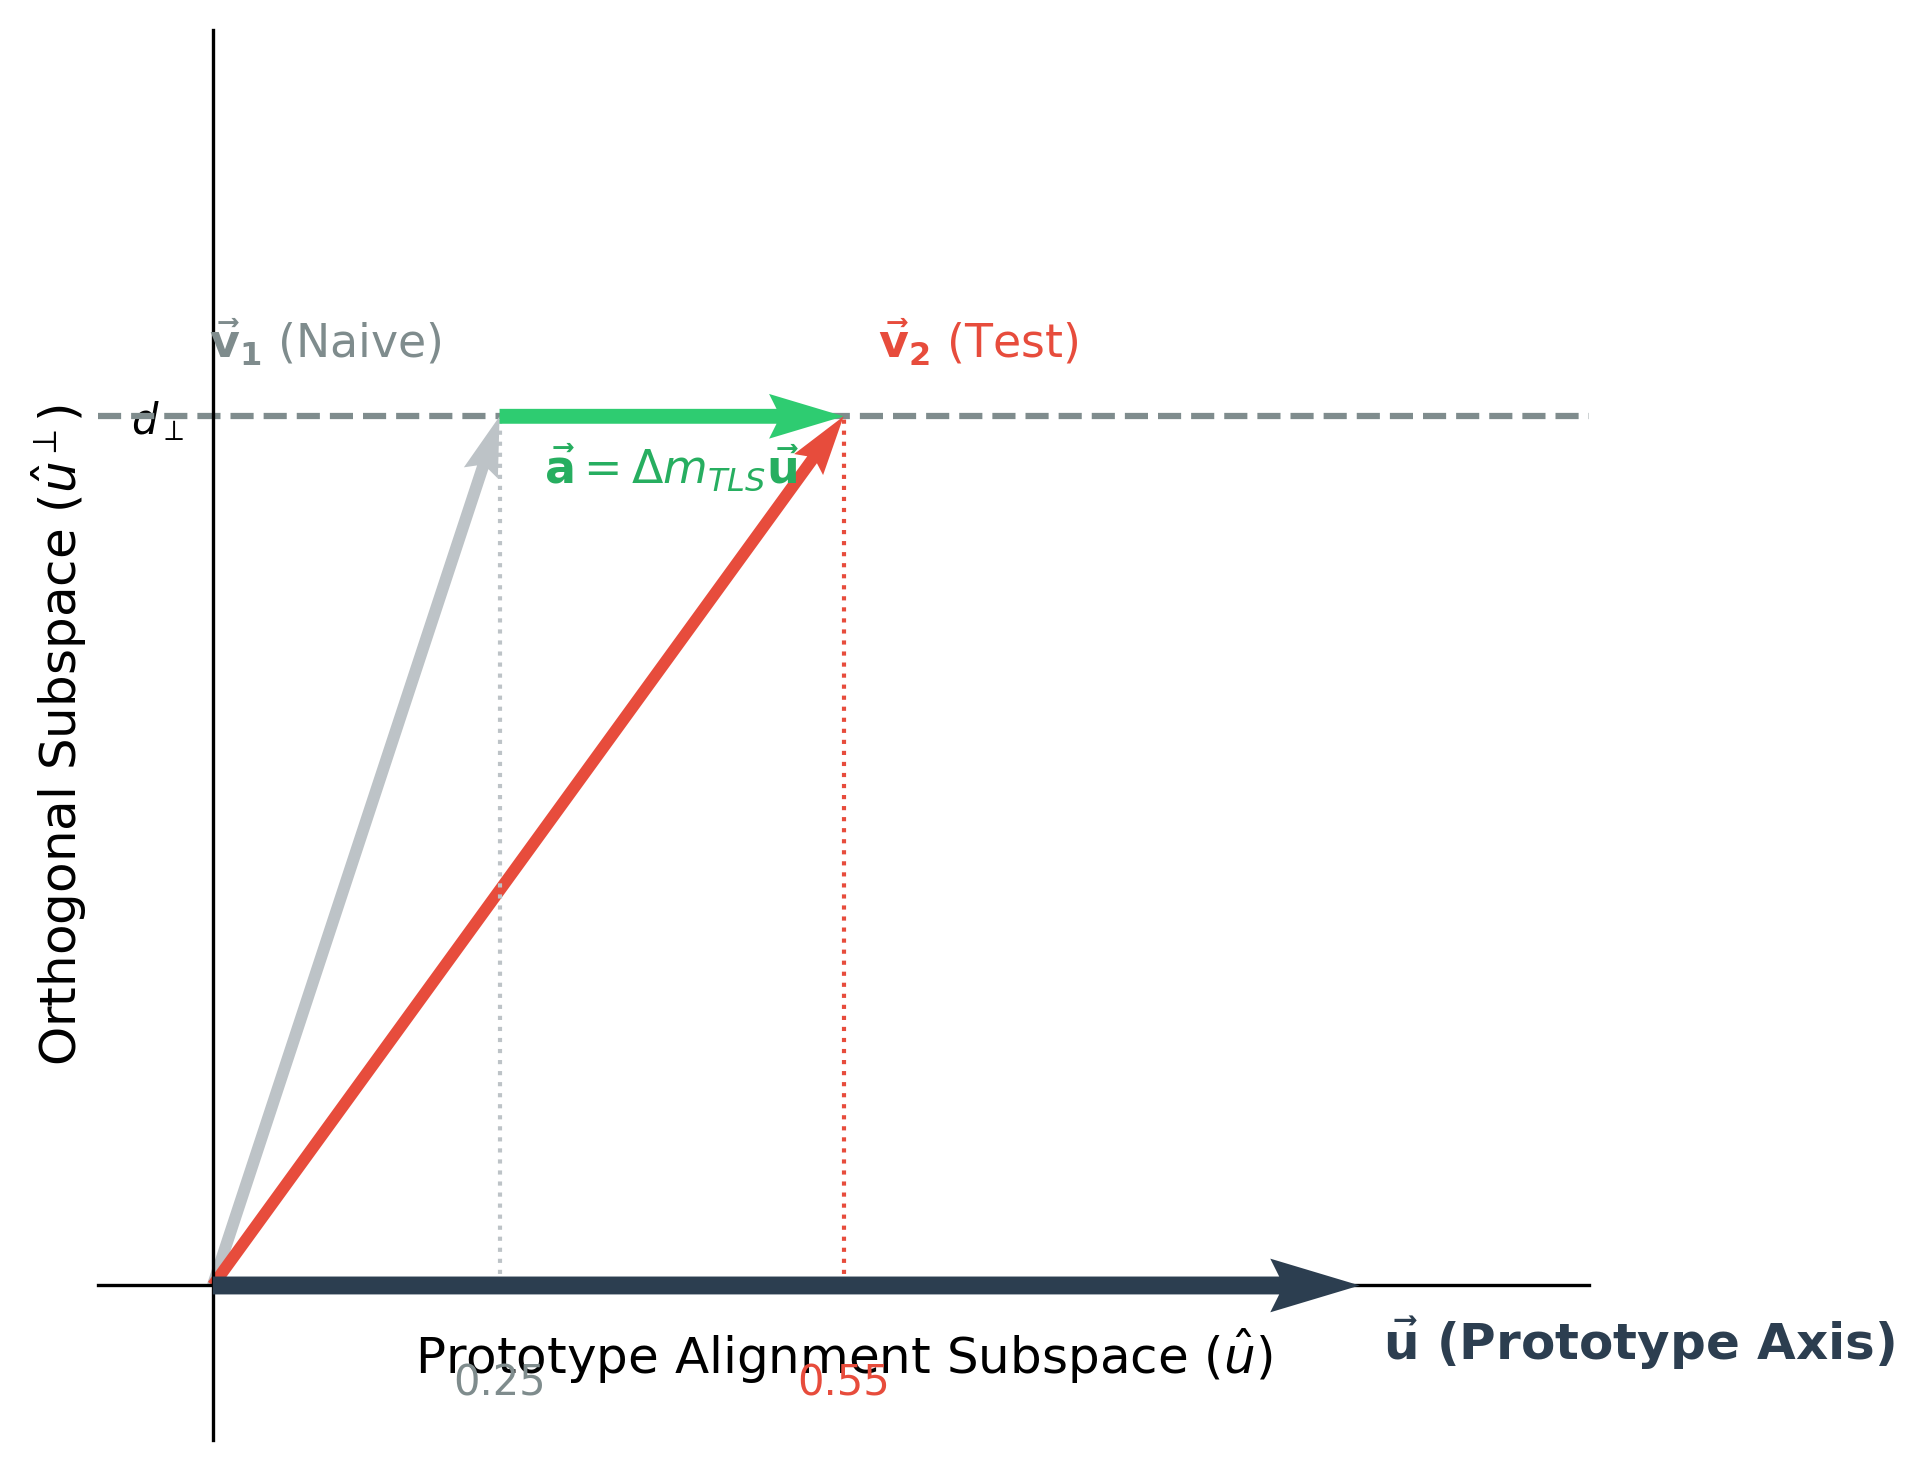

In [88]:
import numpy as np
import matplotlib.pyplot as plt

# Define the empirical values from your data
# (Assuming normalized prototype length ||u|| = 1.0 for geometric clarity)
norm_u = 1.0
m_naive = 0.25
m_test = 0.55
d_perp_val = 0.45  # Constant orthogonal noise floor

# Calculate coordinates
# Vector coordinates are defined as: [horizontal_comp, vertical_comp]
u_vec = np.array([norm_u, 0])
v_naive = np.array([m_naive * norm_u, d_perp_val])
v_test = np.array([m_test * norm_u, d_perp_val])

# Initialize figure
fig, ax = plt.subplots(figsize=(6.5, 5), dpi=300)

# 1. Plot the invariant d_perp ceiling
ax.axhline(y=d_perp_val, color='#7f8c8d', linestyle='--', linewidth=1.5, 
           label=r'Invariant $d_{\perp}$ Floor')

# 2. Draw the Prototype Task Axis baseline
ax.quiver(0, 0, u_vec[0], u_vec[1], angles='xy', scale_units='xy', scale=1,
          color='#2c3e50', width=0.012, zorder=3)
ax.text(u_vec[0] + 0.02, -0.03, r'$\mathbf{\vec{u}}$ (Prototype Axis)', 
        fontsize=12, fontweight='bold', color='#2c3e50', va='center')

# 3. Draw the Naive Vector (v1)
ax.quiver(0, 0, v_naive[0], v_naive[1], angles='xy', scale_units='xy', scale=1,
          color='#bdc3c7', width=0.008, zorder=2)
ax.text(v_naive[0] - 0.05, v_naive[1] + 0.03, r'$\mathbf{\vec{v}_1}$ (Naive)', 
        fontsize=11, color='#7f8c8d', ha='right')

# 4. Draw the Test Vector (v2)
ax.quiver(0, 0, v_test[0], v_test[1], angles='xy', scale_units='xy', scale=1,
          color='#e74c3c', width=0.008, zorder=2)
ax.text(v_test[0] + 0.03, v_test[1] + 0.03, r'$\mathbf{\vec{v}_2}$ (Test)', 
        fontsize=11, color='#e74c3c', ha='left')

# 5. Draw the Additive Gain Vector (a) spanning the tips
# It starts at the tip of v1 and extends by the delta of the slopes
delta_m = m_test - m_naive
ax.quiver(v_naive[0], v_naive[1], delta_m, 0, angles='xy', scale_units='xy', scale=1,
          color='#2ecc71', width=0.01, zorder=4)

# Label the Additive Gain Vector centrally above the arrow
ax.text(v_naive[0] + (delta_m / 2), d_perp_val - 0.04, 
        r'$\mathbf{\vec{a}} = \Delta m_{TLS}\mathbf{\vec{u}}$', 
        fontsize=11, color='#27ae60', ha='center', va='bottom', fontweight='bold')

# 6. Mark the projections on the horizontal axis to visually link to m_TLS
ax.plot([v_naive[0], v_naive[0]], [0, v_naive[1]], color='#bdc3c7', linestyle=':', linewidth=1)
ax.plot([v_test[0], v_test[0]], [0, v_test[1]], color='#e74c3c', linestyle=':', linewidth=1)

# Add tick labels indicating the exact TLS slopes on the axis
ax.text(v_naive[0], -0.04, f'{m_naive}', color='#7f8c8d', ha='center', va='top', fontsize=10)
ax.text(v_test[0], -0.04, f'{m_test}', color='#e74c3c', ha='center', va='top', fontsize=10)

# Final Polish: Axis Limits and Clean Spines
ax.set_xlim(-0.1, 1.2)
ax.set_ylim(-0.08, 0.65)

# Set formal, textbook axis labels
ax.set_xlabel(r'Prototype Alignment Subspace ($\hat{u}$)', fontsize=12, labelpad=10)
ax.set_ylabel(r'Orthogonal Subspace ($\hat{u}^{\perp}$)', fontsize=12, labelpad=10)

# Remove the default frame ticks where numbers aren't needed, use custom styling
ax.set_xticks([])
ax.set_yticks([d_perp_val])
ax.set_yticklabels([r'$d_{\perp}$'], fontsize=12)

# Despine
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_position(('data', 0))
ax.spines['bottom'].set_position(('data', 0))

plt.tight_layout()
plt.show()

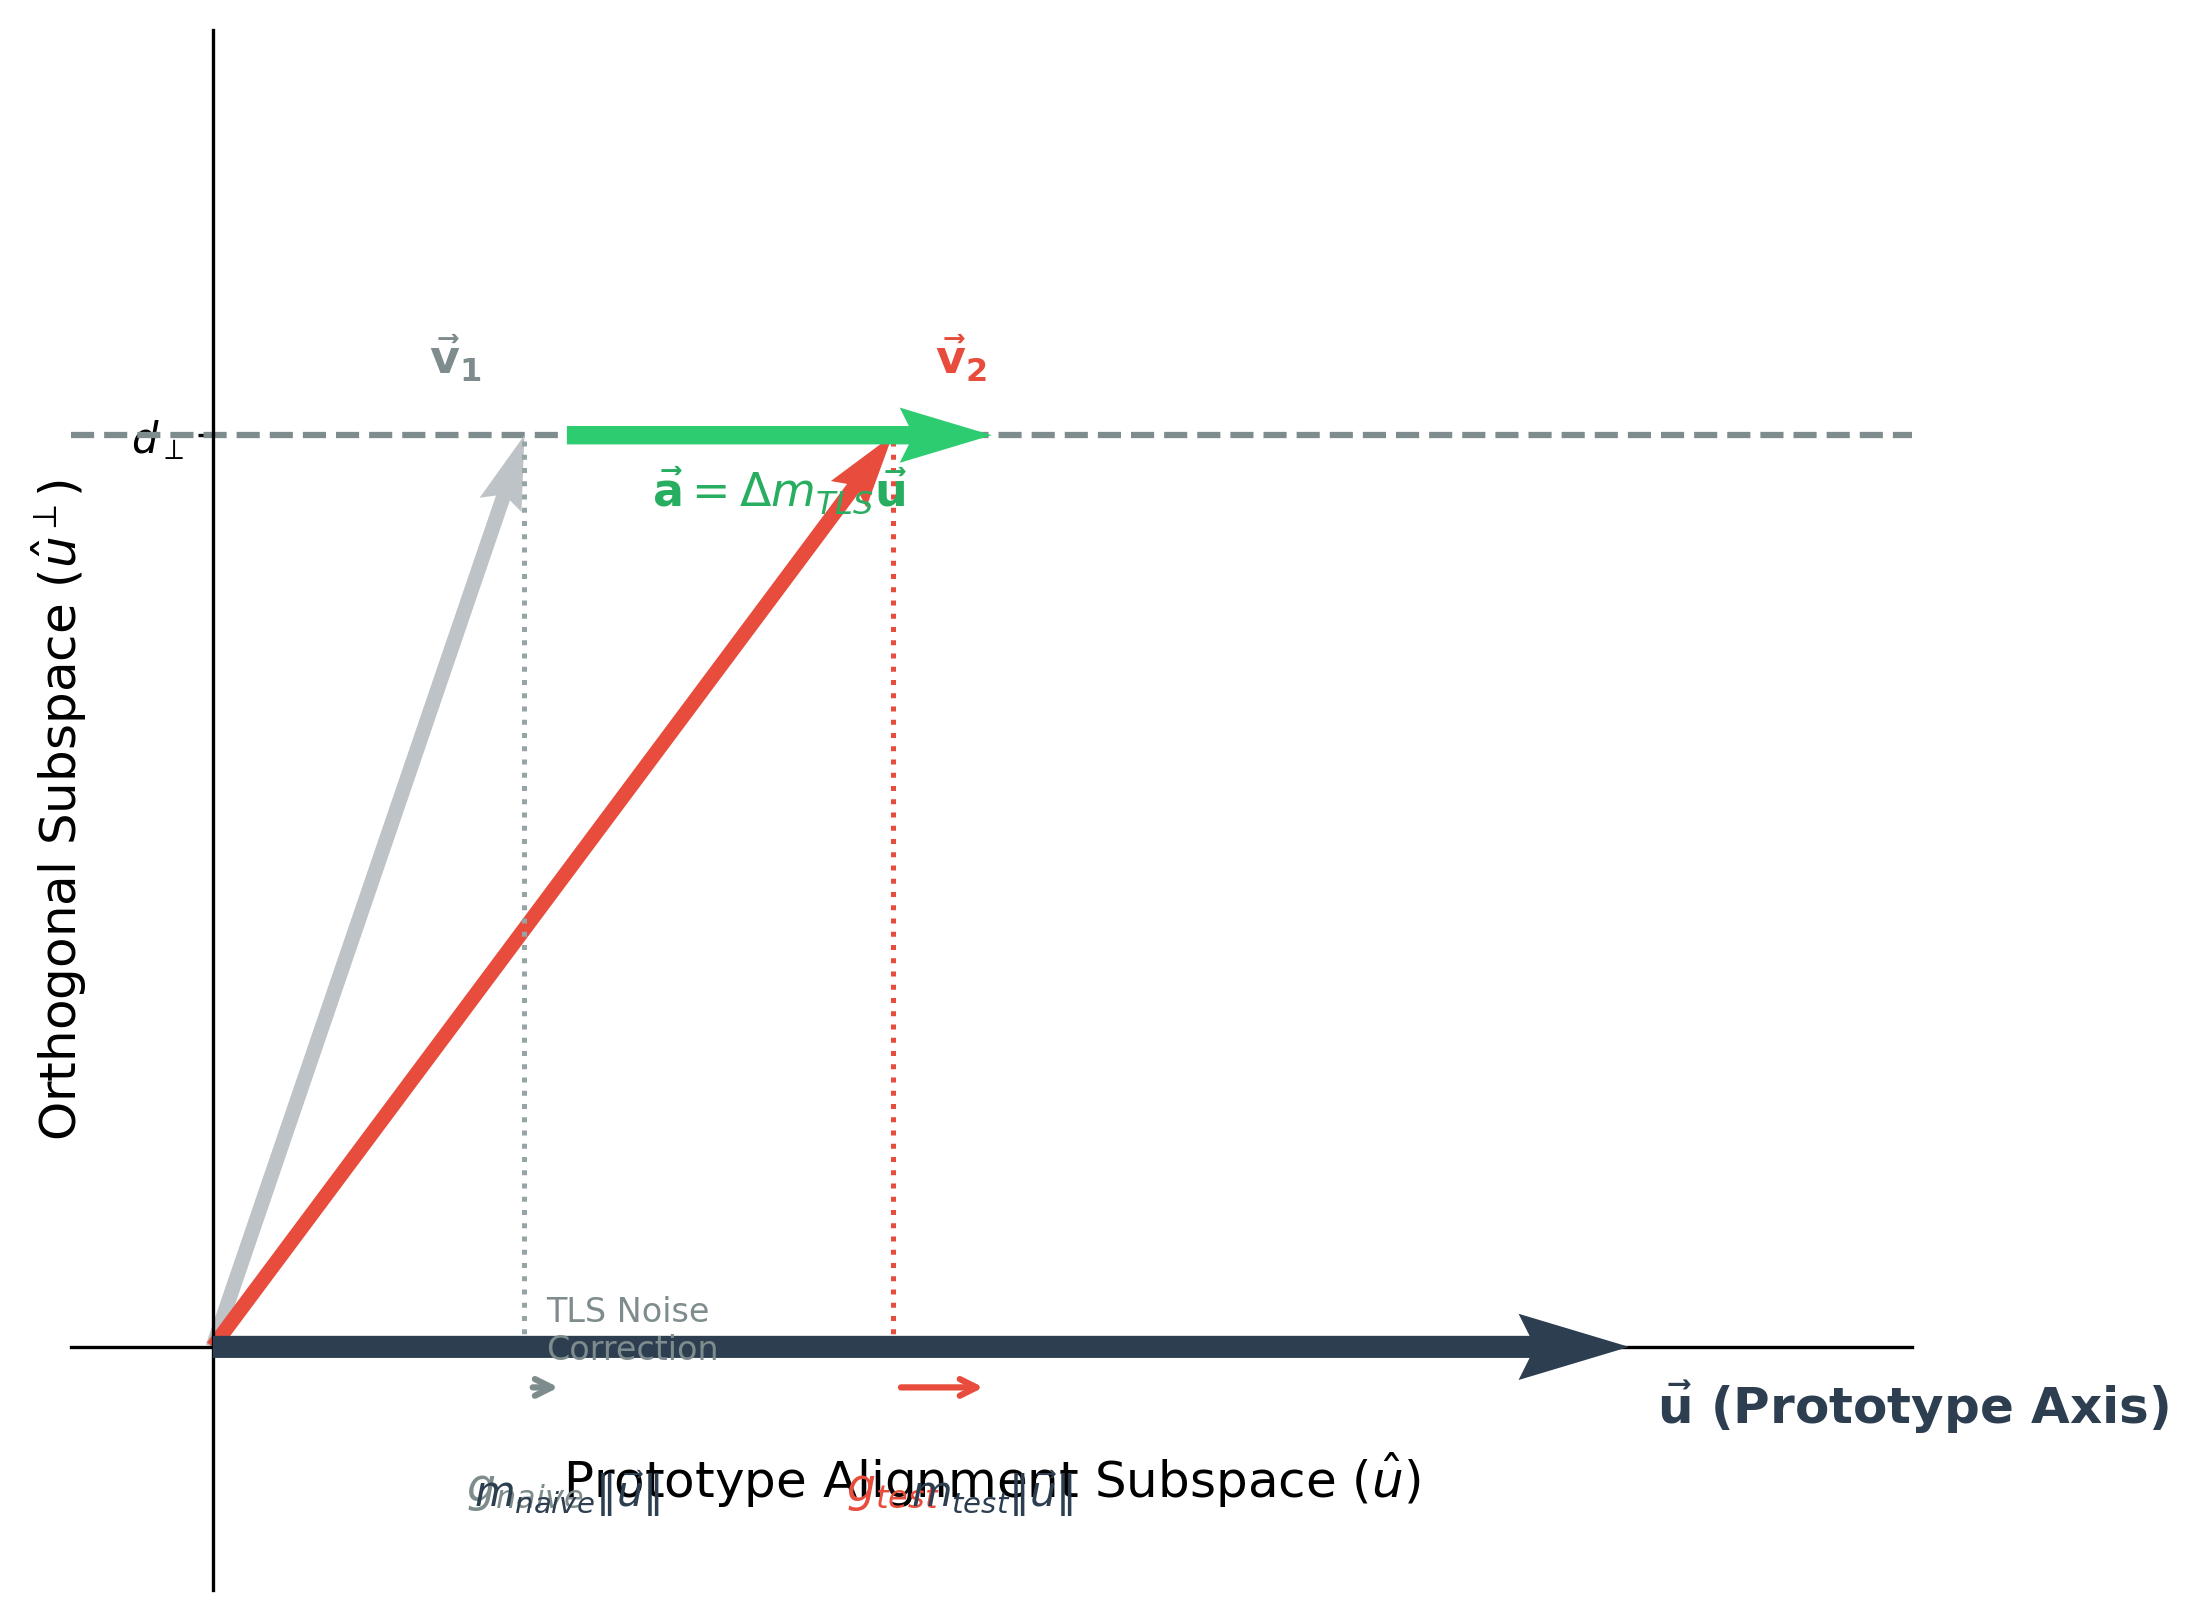

In [89]:

import numpy as np
import matplotlib.pyplot as plt


# Define values showing the attenuation gap (m_ols * ||u|| = g)
norm_u = 1.0
d_perp_val = 0.45  # Constant orthogonal noise floor

# Naive Day values
g_naive = 0.22      # Raw geometric projection (attenuated)
m_naive_tls = 0.25  # True TLS scaled position (noise-corrected)

# Test Day values
g_test = 0.48       # Raw geometric projection (attenuated)
m_test_tls = 0.55   # True TLS scaled position (noise-corrected)

# Vector coordinates
u_vec = np.array([norm_u, 0])
v_naive = np.array([g_naive, d_perp_val]) # The physical vector drops onto g
v_test = np.array([g_test, d_perp_val])

# Initialize figure
fig, ax = plt.subplots(figsize=(7.5, 5.5), dpi=300)

# 1. Plot the invariant d_perp ceiling
ax.axhline(y=d_perp_val, color='#7f8c8d', linestyle='--', linewidth=1.5)

# 2. Draw the Prototype Task Axis baseline
ax.quiver(0, 0, u_vec[0], u_vec[1], angles='xy', scale_units='xy', scale=1,
          color='#2c3e50', width=0.012, zorder=3)
ax.text(u_vec[0] + 0.02, -0.03, r'$\mathbf{\vec{u}}$ (Prototype Axis)', 
        fontsize=12, fontweight='bold', color='#2c3e50', va='center')

# 3. Draw the Naive Vector (v1) dropping onto g_naive
ax.quiver(0, 0, v_naive[0], v_naive[1], angles='xy', scale_units='xy', scale=1,
          color='#bdc3c7', width=0.008, zorder=2)
ax.text(v_naive[0] - 0.03, v_naive[1] + 0.03, r'$\mathbf{\vec{v}_1}$', 
        fontsize=11, color='#7f8c8d', ha='right')

# 4. Draw the Test Vector (v2) dropping onto g_test
ax.quiver(0, 0, v_test[0], v_test[1], angles='xy', scale_units='xy', scale=1,
          color='#e74c3c', width=0.008, zorder=2)
ax.text(v_test[0] + 0.03, v_test[1] + 0.03, r'$\mathbf{\vec{v}_2}$', 
        fontsize=11, color='#e74c3c', ha='left')

# 5. Draw the Additive Gain Vector (a) spanning the TRUE TLS positions
ax.quiver(m_naive_tls, d_perp_val, (m_test_tls - m_naive_tls), 0, 
          angles='xy', scale_units='xy', scale=1, color='#2ecc71', width=0.01, zorder=4)
ax.text(m_naive_tls + (m_test_tls - m_naive_tls)/2, d_perp_val - 0.04, 
        r'$\mathbf{\vec{a}} = \Delta m_{TLS}\mathbf{\vec{u}}$', 
        fontsize=11, color='#27ae60', ha='center', va='bottom', fontweight='bold')

# 6. Drop dashed lines to the RAW projection 'g' on the axis
ax.plot([g_naive, g_naive], [0, v_naive[1]], color='#95a5a6', linestyle=':', linewidth=1.2)
ax.plot([g_test, g_test], [0, v_test[1]], color='#e74c3c', linestyle=':', linewidth=1.2)

# 7. Draw the TLS Correction Shifts on the Axis (g -> m_TLS)
# Naive shift arrow
ax.annotate('', xy=(m_naive_tls, -0.02), xytext=(g_naive, -0.02),
            arrowprops=dict(arrowstyle="->", color='#7f8c8d', lw=1.5))
# Test shift arrow
ax.annotate('', xy=(m_test_tls, -0.02), xytext=(g_test, -0.02),
            arrowprops=dict(arrowstyle="->", color='#e74c3c', lw=1.5))

# Labels for the axis entries
ax.text(g_naive, -0.06, r'$g_{naive}$', color='#7f8c8d', ha='center', va='top', fontsize=11)
ax.text(m_naive_tls, -0.06, r'$m_{naive}\|\vec{u}\|$', color='#2c3e50', ha='center', va='top', fontsize=10)

ax.text(g_test, -0.06, r'$g_{test}$', color='#e74c3c', ha='center', va='top', fontsize=11)
ax.text(m_test_tls, -0.06, r'$m_{test}\|\vec{u}\|$', color='#2c3e50', ha='center', va='top', fontsize=10)

# Text annotation to explain the gap to the reviewer
ax.text(g_naive + 0.015, -0.01, 'TLS Noise\nCorrection', color='#7f8c8d', fontsize=8, ha='left', va='bottom')

# Final Polish
ax.set_xlim(-0.1, 1.2)
ax.set_ylim(-0.12, 0.65)
ax.set_xlabel(r'Prototype Alignment Subspace ($\hat{u}$)', fontsize=12, labelpad=25)
ax.set_ylabel(r'Orthogonal Subspace ($\hat{u}^{\perp}$)', fontsize=12, labelpad=10)

ax.set_xticks([])
ax.set_yticks([d_perp_val])
ax.set_yticklabels([r'$d_{\perp}$'], fontsize=12)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_position(('data', 0))
ax.spines['bottom'].set_position(('data', 0))

plt.tight_layout()
plt.show()